# Day 2 — EDA: NASA CMAPSS Turbofan Dataset (FD001)

Goal: understand the sensor data well enough to engineer a sound feature
schema for Day 3's XGBoost model. We'll define Remaining Useful Life (RUL),
inspect sensor behavior as engines approach failure, and lock in the feature
set + a binary failure label.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Load the data

The file is whitespace-separated with no header row. 26 columns:
`unit_nr`, `time_cycles`, 3 operational settings, 21 sensor readings.

In [2]:
index_names = ["unit_nr", "time_cycles"]
setting_names = ["setting_1", "setting_2", "setting_3"]
sensor_names = [f"s_{i}" for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

df = pd.read_csv("data/train_FD001.txt", sep=r"\s+", header=None, names=col_names)

print(f"Shape: {df.shape}")
print(f"Unique engines: {df['unit_nr'].nunique()}")
df.head()

Shape: (20631, 26)
Unique engines: 100


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Compute Remaining Useful Life (RUL)

Each engine in this file runs all the way to failure, so for any row we
can compute RUL retrospectively: `RUL = max_cycle_for_this_engine - current_cycle`.
This becomes our regression target (and the basis for our binary label).

In [3]:
max_cycles = df.groupby("unit_nr")["time_cycles"].transform("max")
df["RUL"] = max_cycles - df["time_cycles"]

df[["unit_nr", "time_cycles", "RUL"]].head(10)

,unit_nr,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


## 3. Distribution of engine lifespans

Sanity check: do engine lifespans look reasonable (no single-cycle engines,
no absurd outliers)?

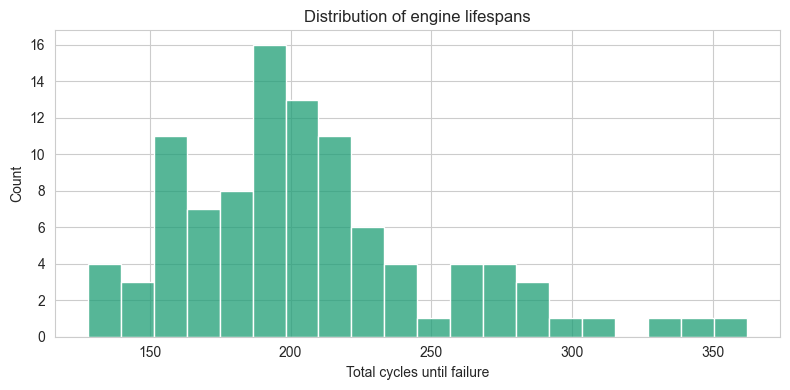

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_cycles, dtype: float64


In [4]:
lifespans = df.groupby("unit_nr")["time_cycles"].max()

plt.figure(figsize=(8, 4))
sns.histplot(lifespans, bins=20, color="#1D9E75")
plt.xlabel("Total cycles until failure")
plt.title("Distribution of engine lifespans")
plt.tight_layout()
plt.savefig("output_lifespan_dist.png", dpi=100)
plt.show()

print(lifespans.describe())

## 4. Sensor behavior over an engine's life

Pick a handful of sensors and plot them against RUL for a few engines.
We're looking for sensors that show a clear trend (drift) as RUL approaches
zero — those are the ones worth engineering features from. Flat, noisy
sensors with no trend add little predictive value.

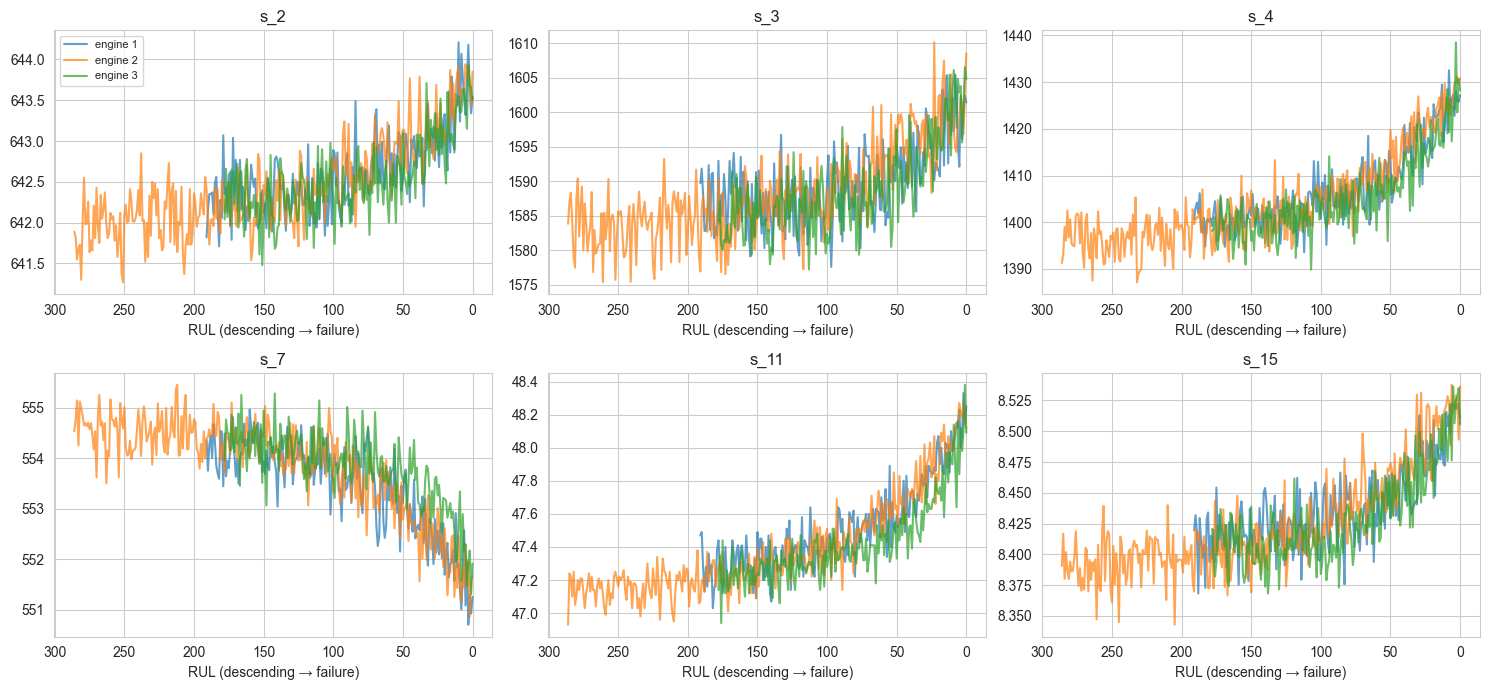

In [5]:
sample_units = [1, 2, 3]
sensors_to_check = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_15"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, sensor in zip(axes.flat, sensors_to_check):
    for unit in sample_units:
        sub = df[df["unit_nr"] == unit]
        ax.plot(sub["RUL"], sub[sensor], alpha=0.7, label=f"engine {unit}")
    ax.invert_xaxis()  # RUL decreasing left-to-right = approaching failure
    ax.set_title(sensor)
    ax.set_xlabel("RUL (descending → failure)")
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("output_sensor_trends.png", dpi=100)
plt.show()

## 5. Correlation with RUL

Rank every sensor by how strongly it correlates with RUL. The top ones are
our best candidates for feature engineering — they carry the most signal
about engine health.

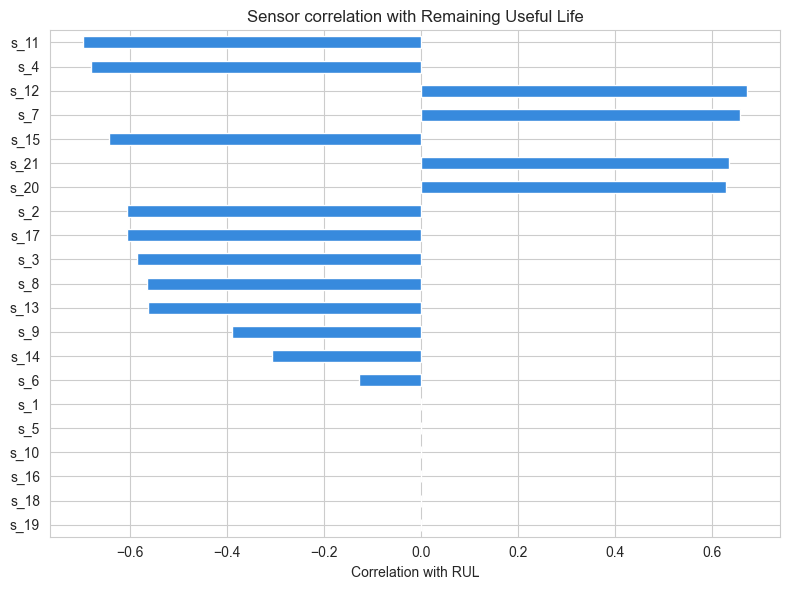

Top 10 sensors by |correlation| with RUL:
s_11   -0.696228
s_4    -0.678948
s_12    0.671983
s_7     0.657223
s_15   -0.642667
s_21    0.635662
s_20    0.629428
s_2    -0.606484
s_17   -0.606154
s_3    -0.584520
Name: RUL, dtype: float64


In [6]:
corr_with_rul = (
    df[sensor_names + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(8, 6))
corr_with_rul.plot(kind="barh", color="#378ADD")
plt.xlabel("Correlation with RUL")
plt.title("Sensor correlation with Remaining Useful Life")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("output_correlation.png", dpi=100)
plt.show()

print("Top 10 sensors by |correlation| with RUL:")
print(corr_with_rul.head(10))

## 6. Drop flat / constant sensors

Some sensors in CMAPSS data are known to be constant or near-constant
(no useful signal). Check standard deviation per sensor and flag any
with near-zero variance — these get dropped from the feature set.

In [7]:
sensor_std = df[sensor_names].std().sort_values()
print("Sensors with lowest variance (candidates to drop):")
print(sensor_std.head(8))

low_variance_sensors = sensor_std[sensor_std < 1e-3].index.tolist()
print(f"\nDropping (near-zero variance): {low_variance_sensors}")

useful_sensors = [s for s in sensor_names if s not in low_variance_sensors]
print(f"Remaining usable sensors: {len(useful_sensors)}")

Sensors with lowest variance (candidates to drop):
s_1     0.000000e+00
s_10    0.000000e+00
s_19    0.000000e+00
s_18    0.000000e+00
s_16    3.469531e-18
s_5     5.329200e-15
s_6     1.388985e-03
s_15    3.750504e-02
dtype: float64

Dropping (near-zero variance): ['s_1', 's_10', 's_19', 's_18', 's_16', 's_5']
Remaining usable sensors: 15


## 7. Final feature set — pick top sensors + engineer rolling features

Based on correlation strength, select the top sensors. For each, we'll
compute a 7-cycle rolling mean and rolling std per engine — this captures
*trend*, not just instantaneous value, which is what actually predicts
imminent failure. This rolling-window definition is exactly what we'll
replicate in the Redis feature store on Day 4, so getting it precise here
matters — any mismatch later is training-serving skew.

In [8]:
TOP_N = 10
top_sensors = (
    corr_with_rul.drop(labels=low_variance_sensors, errors="ignore")
    .head(TOP_N)
    .index.tolist()
)
print(f"Selected top {TOP_N} sensors:", top_sensors)

ROLLING_WINDOW = 7

feature_rows = []
for sensor in top_sensors:
    df[f"{sensor}_rolling_mean_{ROLLING_WINDOW}"] = df.groupby("unit_nr")[sensor].transform(
        lambda x: x.rolling(ROLLING_WINDOW, min_periods=1).mean()
    )
    df[f"{sensor}_rolling_std_{ROLLING_WINDOW}"] = df.groupby("unit_nr")[sensor].transform(
        lambda x: x.rolling(ROLLING_WINDOW, min_periods=1).std().fillna(0)
    )

engineered_cols = [c for c in df.columns if "rolling" in c]
print(f"\nEngineered {len(engineered_cols)} rolling features.")
df[["unit_nr", "time_cycles", "RUL"] + engineered_cols].head()

Selected top 10 sensors: ['s_11', 's_4', 's_12', 's_7', 's_15', 's_21', 's_20', 's_2', 's_17', 's_3']

Engineered 20 rolling features.


,unit_nr,time_cycles,RUL,s_11_rolling_mean_7,s_11_rolling_std_7,s_4_rolling_mean_7,s_4_rolling_std_7,s_12_rolling_mean_7,s_12_rolling_std_7,s_7_rolling_mean_7,s_7_rolling_std_7,s_15_rolling_mean_7,s_15_rolling_std_7,s_21_rolling_mean_7,s_21_rolling_std_7,s_20_rolling_mean_7,s_20_rolling_std_7,s_2_rolling_mean_7,s_2_rolling_std_7,s_17_rolling_mean_7,s_17_rolling_std_7,s_3_rolling_mean_7,s_3_rolling_std_7
0,1,1,191,47.470,0.000000,1400.600000,0.000000,521.660,0.000000,554.360000,0.000000,8.419500,0.000000,23.419000,0.000000,39.060000,0.000000,641.820000,0.000000,392.000000,0.000000,1589.700000,0.000000
1,1,2,190,47.480,0.014142,1401.870000,1.796051,521.970,0.438406,554.055000,0.431335,8.425650,0.008697,23.421300,0.003253,39.030000,0.042426,641.985000,0.233345,392.000000,0.000000,1590.760000,1.499066
2,1,3,189,47.410,0.121655,1402.646667,1.850009,522.120,0.404475,554.123333,0.327159,8.423033,0.007640,23.395600,0.044573,39.003333,0.055076,642.106667,0.267644,391.333333,1.154701,1589.836667,1.918654
3,1,4,188,47.340,0.171659,1402.452500,1.559645,522.305,0.495950,554.205000,0.313103,8.409325,0.028117,23.390175,0.037977,38.972500,0.076322,642.167500,0.250117,391.500000,1.000000,1588.075000,3.855909
4,1,5,187,47.328,0.151063,1403.206000,2.159440,522.282,0.432574,554.164000,0.286234,8.413340,0.025953,23.393020,0.033498,38.958000,0.073621,642.208000,0.234776,391.800000,1.095445,1587.030000,4.075678


## 8. Define the binary failure label

`failure_soon = 1` when RUL < 30 cycles — this is the threshold the
XGBoost classifier will be trained to predict on Day 3. 30 is a common
choice in CMAPSS literature; it gives a meaningful early-warning window
without being so wide that the label loses precision.

In [9]:
RUL_THRESHOLD = 30
df["failure_soon"] = (df["RUL"] < RUL_THRESHOLD).astype(int)

print(df["failure_soon"].value_counts())
print(f"\nPositive class rate: {df['failure_soon'].mean():.2%}")

failure_soon
0    17631
1     3000
Name: count, dtype: int64

Positive class rate: 14.54%


## 9. Save the feature schema

This JSON is the contract between training (today), the model (Day 3),
and the live feature store (Day 4). Every system downstream must agree
on exactly these field names, in this order, with this rolling window —
that agreement is what prevents training-serving skew.

In [10]:
import json

feature_schema = {
    "rolling_window": ROLLING_WINDOW,
    "rul_threshold": RUL_THRESHOLD,
    "top_sensors": top_sensors,
    "feature_columns": engineered_cols,
    "dropped_low_variance_sensors": low_variance_sensors,
    "label_column": "failure_soon",
}

with open("../artifacts/feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

print("Saved feature_schema.json:")
print(json.dumps(feature_schema, indent=2))

Saved feature_schema.json:
{
  "rolling_window": 7,
  "rul_threshold": 30,
  "top_sensors": [
    "s_11",
    "s_4",
    "s_12",
    "s_7",
    "s_15",
    "s_21",
    "s_20",
    "s_2",
    "s_17",
    "s_3"
  ],
  "feature_columns": [
    "s_11_rolling_mean_7",
    "s_11_rolling_std_7",
    "s_4_rolling_mean_7",
    "s_4_rolling_std_7",
    "s_12_rolling_mean_7",
    "s_12_rolling_std_7",
    "s_7_rolling_mean_7",
    "s_7_rolling_std_7",
    "s_15_rolling_mean_7",
    "s_15_rolling_std_7",
    "s_21_rolling_mean_7",
    "s_21_rolling_std_7",
    "s_20_rolling_mean_7",
    "s_20_rolling_std_7",
    "s_2_rolling_mean_7",
    "s_2_rolling_std_7",
    "s_17_rolling_mean_7",
    "s_17_rolling_std_7",
    "s_3_rolling_mean_7",
    "s_3_rolling_std_7"
  ],
  "dropped_low_variance_sensors": [
    "s_1",
    "s_10",
    "s_19",
    "s_18",
    "s_16",
    "s_5"
  ],
  "label_column": "failure_soon"
}


## Summary

- Loaded {n_engines} engines, computed RUL per row
- Identified top {TOP_N} predictive sensors by correlation with RUL
- Dropped near-constant sensors (no signal)
- Engineered rolling mean/std features (7-cycle window) — this exact
  definition will be replicated in Redis on Day 4
- Defined binary label: `failure_soon = RUL < 30`
- Saved the feature schema to `artifacts/feature_schema.json` for
  Day 3 (training) and Day 4 (feature store) to consume

**Next:** Day 3 trains XGBoost on these engineered features.